# Dynamic Pricing & Elasticity — Fast Transaction Services (FastPay)

An interactive walkthrough of the case study. For the full written explanation
see [`dynamic_pricing_and_elasticity_case_study.md`](dynamic_pricing_and_elasticity_case_study.md).

**Storyline**
1. Simulate a real-time-payments panel with a *known* elasticity and a *surge*
   (endogenous) fee policy.
2. Show that naive log-log OLS is badly biased, and that an IV/2SLS estimator
   using a cost-shock instrument recovers the truth.
3. Turn the elasticity into a price and show a biased elasticity loses ~45% of profit.
4. Price dynamically: flat fee vs guarded surge vs contextual bandits.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fast_txn_simulator import SimConfig, generate_fast_txn_data, segment_truth
from elasticity_models import (point_elasticity, arc_elasticity,
                               naive_ols_elasticity, iv_2sls_elasticity,
                               first_stage_strength, segmented_elasticity)
from dynamic_pricing import (lerner_optimal_fee, profit_curve, optimal_fee_grid,
                             TxnPricingEnv, StaticController, SurgeController,
                             ThompsonBanditController, EpsilonGreedyController,
                             run_simulation)

plt.rcParams.update({'figure.figsize': (9, 5), 'axes.grid': True, 'grid.alpha': .25})
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

## 1. Simulate the FastPay panel

The simulator bakes in the structural truth so we can score estimators:
- a known **elasticity** per segment,
- a **surge** fee policy: the firm raises the fee when latent demand `u` is high
  (this is what creates endogeneity),
- a **cost shock** `z` (processing/interchange) that shifts the fee but not demand
  directly — our instrument.


In [2]:
df = generate_fast_txn_data(SimConfig())
print(f'{len(df):,} hourly rows x {df.segment.nunique()} segments')
display(df.groupby('segment')[['fee_rate','volume','unit_cost','profit','load']].mean())
print('\nGround truth:'); display(segment_truth())

8,640 hourly rows x 3 segments


,fee_rate,volume,unit_cost,profit,load
segment,,,,,
consumer,0.013,"15,424.318",0.182,"23,480.495",0.497
enterprise,0.009,281.986,0.303,293.526,0.497
smb,0.011,"2,079.716",0.223,"2,967.823",0.497



Ground truth:


,segment,true_elasticity,base_cost,base_fee
0,consumer,-1.900,0.180,0.012
1,smb,-1.350,0.220,0.010
2,enterprise,-0.850,0.300,0.008


## 2. Two-point (arc/point) elasticity — the schoolbook version

A quick sanity check on the consumer segment: bucket by fee and compare the
cheapest vs priciest bucket. (This is descriptive, *not* causal — it still mixes
in the demand shock.)


In [3]:
c = df[df.segment=='consumer'].copy()
c['fee_bucket'] = pd.qcut(c.fee_rate, 5)
g = c.groupby('fee_bucket').agg(fee=('fee_rate','mean'), vol=('volume','mean'))
lo, hi = g.iloc[0], g.iloc[-1]
print('Naive arc elasticity (low vs high fee bucket):',
      round(arc_elasticity(lo.vol, hi.vol, lo.fee, hi.fee), 3))
print('(Biased — high-fee buckets are also high-demand hours.)')

Naive arc elasticity (low vs high fee bucket): -0.977
(Biased — high-fee buckets are also high-demand hours.)


## 3. Elasticity: naive OLS (biased) vs IV/2SLS (causal)

The log-log OLS slope conflates the demand curve with the firm's surge policy.
A cost-shock instrument breaks that — check the strong first stage.


In [4]:
print('Pooled OLS:', naive_ols_elasticity(df))
print('Pooled IV :', iv_2sls_elasticity(df))
print('First-stage strength:', first_stage_strength(df))

table = segmented_elasticity(df)
display(table[['segment','true_elasticity','ols_elasticity','iv_elasticity',
               'first_stage_F','ols_bias','iv_bias']])

Pooled OLS: {'method': 'OLS (log-log)', 'elasticity': 0.3946674819847613, 'se': 0.03669684537287692, 'n': 8640}
Pooled IV : {'method': 'IV / 2SLS', 'elasticity': -1.3310775276271012, 'se': 0.058708662247745624, 'n': 8640, 'first_stage_F': 8323.286947478971}
First-stage strength: {'instrument_coef': 0.6210312665958367, 'instrument_se': 0.006807161152089891, 'F_stat': 8323.286947478971, 'n': 8640}


,segment,true_elasticity,ols_elasticity,iv_elasticity,first_stage_F,ols_bias,iv_bias
0,consumer,-1.900,-1.146,-1.883,"2,191.800",0.754,0.017
1,smb,-1.350,-0.723,-1.343,"3,313.671",0.627,0.007
2,enterprise,-0.850,-0.445,-0.857,"6,883.758",0.405,-0.007


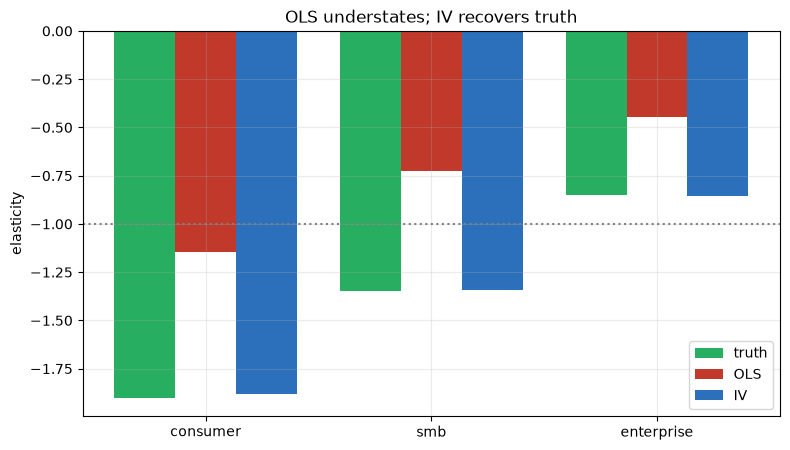

In [5]:
fig, ax = plt.subplots()
x = np.arange(len(table)); w = .27
ax.bar(x-w, table.true_elasticity, w, label='truth', color='#27ae60')
ax.bar(x,   table.ols_elasticity, w, label='OLS',   color='#c0392b')
ax.bar(x+w, table.iv_elasticity,  w, label='IV',    color='#2c6fbb')
ax.set_xticks(x); ax.set_xticklabels(table.segment); ax.axhline(-1, ls=':', c='gray')
ax.set_ylabel('elasticity'); ax.legend(); ax.set_title('OLS understates; IV recovers truth')
plt.show()

**Takeaway.** OLS understates price sensitivity by ~40–50%, and the *pooled*
OLS estimate is even positive. IV lands within ~0.02 of the truth.


## 4. From elasticity to price — and the cost of getting it wrong

The Lerner rule: optimal markup = −1/ε. We calibrate the live environment so the
current 1.2% fee is myopically optimal at average load, then compare the fee you'd
*choose* from the true vs the biased elasticity.


In [6]:
seg = table[table.segment=='consumer'].iloc[0]
fee_ref, q_ref, ticket = 0.012, 15000., 150.
env = TxnPricingEnv.calibrated(elasticity=seg.true_elasticity, fee_ref=fee_ref,
                               q_ref=q_ref, avg_ticket=ticket)
cost = env.base_cost
grid = np.linspace(0.004, env.fee_bounds[1], 200)
curve = profit_curve(seg.true_elasticity, q_ref, fee_ref, cost, ticket, grid)
opt = optimal_fee_grid(curve)

def implied(eps): return lerner_optimal_fee(eps, cost, ticket, env.fee_bounds)['optimal_fee']
def tprofit(f):   return profit_curve(seg.true_elasticity, q_ref, fee_ref, cost, ticket,
                                      np.array([f])).profit.iloc[0]

f_iv, f_ols = implied(seg.iv_elasticity), implied(seg.ols_elasticity)
print(f'Optimal (IV)  fee {f_iv*100:.2f}%  -> profit/period ${tprofit(f_iv):,.0f}')
print(f'Implied (OLS) fee {f_ols*100:.2f}%  -> profit/period ${tprofit(f_ols):,.0f}')
print(f'Profit lost by pricing on OLS: {(1-tprofit(f_ols)/tprofit(f_iv))*100:.0f}%')

Optimal (IV)  fee 1.21%  -> profit/period $14,209
Implied (OLS) fee 4.00%  -> profit/period $7,838
Profit lost by pricing on OLS: 45%


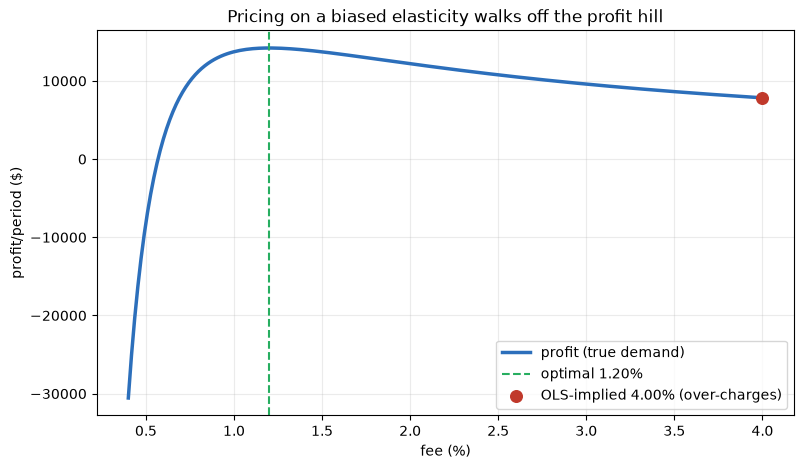

In [7]:
fig, ax = plt.subplots()
ax.plot(curve.fee*100, curve.profit, color='#2c6fbb', lw=2.5, label='profit (true demand)')
ax.axvline(opt['optimal_fee']*100, color='#27ae60', ls='--', label=f"optimal {opt['optimal_fee']*100:.2f}%")
ax.scatter([f_ols*100],[tprofit(f_ols)], color='#c0392b', s=70, zorder=5,
           label=f'OLS-implied {f_ols*100:.2f}% (over-charges)')
ax.set_xlabel('fee (%)'); ax.set_ylabel('profit/period ($)'); ax.legend()
ax.set_title('Pricing on a biased elasticity walks off the profit hill'); plt.show()

## 5. Dynamic pricing: static vs guarded surge vs contextual bandits

Marginal cost rises with load, so the optimal fee is higher at peak. We score
each controller against a load-aware oracle on the same demand path.


In [8]:
fee_grid = np.round(np.arange(0.006, 0.0301, 0.002), 4)
controllers = {
    'static_1.2%':    StaticController(fee_ref, name='static_1.2%'),
    'surge_rule':     SurgeController(base_fee=fee_ref, fee_bounds=env.fee_bounds),
    'epsilon_greedy': EpsilonGreedyController(fee_grid, 5, epsilon=.1),
    'thompson_bandit':ThompsonBanditController(fee_grid, 5),
}
res = run_simulation(env, controllers, fee_grid, T=5000, n_contexts=5, seed=7)
oracle = res['_oracle']['total_profit']
for k in ['static_1.2%','surge_rule','epsilon_greedy','thompson_bandit']:
    tp = res[k]['total_profit']
    print(f'{k:16s} ${tp:14,.0f}  {100*tp/oracle:5.1f}% of oracle')
print(f'Surge uplift over flat fee: '
      f"{res['surge_rule']['total_profit']/res['static_1.2%']['total_profit']-1:.1%}")

static_1.2%      $    53,772,374   80.5% of oracle
surge_rule       $    63,941,282   95.7% of oracle
epsilon_greedy   $    63,146,018   94.5% of oracle
thompson_bandit  $    60,928,625   91.2% of oracle
Surge uplift over flat fee: 18.9%


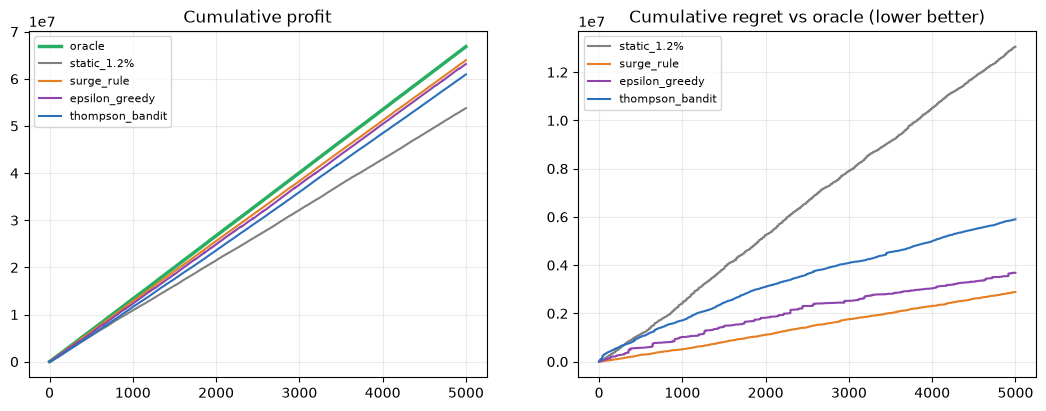

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
cols = {'static_1.2%':'gray','surge_rule':'#e67e22','epsilon_greedy':'#8e44ad','thompson_bandit':'#2c6fbb'}
axs[0].plot(res['_oracle']['cum_profit'], color='#27ae60', lw=2.5, label='oracle')
for k,c in cols.items(): axs[0].plot(res[k]['cum_profit'], color=c, label=k)
axs[0].set_title('Cumulative profit'); axs[0].legend(fontsize=8)
for k,c in cols.items(): axs[1].plot(res[k]['regret'], color=c, label=k)
axs[1].set_title('Cumulative regret vs oracle (lower better)'); axs[1].legend(fontsize=8)
plt.show()

**Takeaways**
- Load-aware dynamic pricing lifts profit ~19% over a flat fee.
- A simple, auditable surge rule (with floor/cap/rate-limit guardrails) is very
  strong when the structure is known; contextual bandits *learn* the policy online
  when it isn't.
- The static policy's regret grows linearly (it never learns); the learners' regret
  flattens.

Next: read the full explainer for identification details, DML/causal forests for
heterogeneous elasticity, RL, and the production guardrails (fairness, feedback
loops, monitoring).
